Calibration Results:
alpha: 2.0000
beta: 0.5000
rho: 0.0168
nu: 2.0000
error: 0.0163


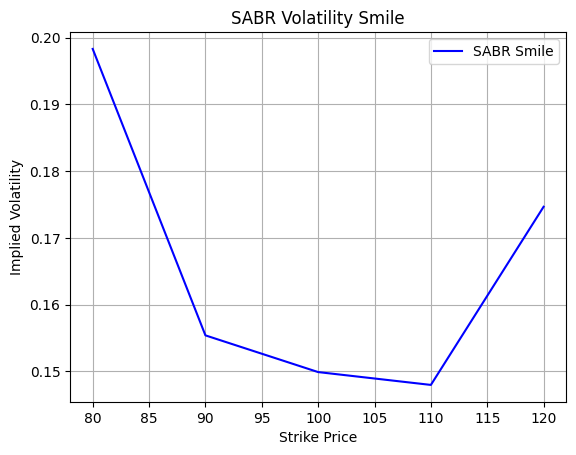

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

class SABRModel:
    def __init__(self):
        self.alpha = None  # Initial volatility
        self.beta = None   # Elasticity parameter
        self.rho = None    # Correlation between asset price and volatility
        self.nu = None     # Volatility of volatility
        
    def sabr_volatility(self, F, K, T, alpha, beta, rho, nu):
        """
        Calculate SABR implied volatility
        F: Forward price
        K: Strike price
        T: Time to maturity
        """
        if F == K:
            X = 0
            vol = alpha / (F**(1-beta))
            return vol / (1 + ((1-beta)**2/24 * alpha**2/(F**(2-2*beta)) + 
                             rho*beta*nu*alpha/(4*(F**(1-beta))) + 
                             (2-3*rho**2)*nu**2/24)*T)
        
        z = (nu/alpha) * (F*K)**((1-beta)/2) * np.log(F/K)
        X = np.log((np.sqrt(1-2*rho*z+z**2) + z - rho)/(1-rho))
        
        vol = alpha * (1-beta) * z / (X * (F*K)**((1-beta)/2))
        correction = (1 + ((1-beta)**2/24 * alpha**2/((F*K)**(1-beta)) + 
                         rho*beta*nu*alpha/(4*((F*K)**((1-beta)/2))) + 
                         (2-3*rho**2)*nu**2/24)*T)
        
        return vol * correction

    def objective_function(self, params, F, strikes, market_vols, T):
        """
        Objective function to minimize: difference between SABR and market volatilities
        """
        alpha, rho, nu = params  # beta is often fixed
        beta = self.beta
        
        # Ensure reasonable parameter bounds
        if alpha <= 0 or nu <= 0 or rho <= -1 or rho >= 1:
            return np.inf
            
        sabr_vols = [self.sabr_volatility(F, K, T, alpha, beta, rho, nu) 
                    for K in strikes]
        
        return np.sum((np.array(sabr_vols) - market_vols)**2)

    def calibrate(self, F, strikes, market_vols, T, beta=0.5,
                 initial_params=[0.2, 0.0, 0.3]):
        """
        Calibrate SABR model to market data
        F: Forward price
        strikes: Array of strike prices
        market_vols: Array of market implied volatilities
        T: Time to maturity
        beta: Fixed beta parameter (default 0.5)
        initial_params: [alpha, rho, nu]
        """
        self.beta = beta
        
        # Bounds for parameters: alpha > 0, -1 < rho < 1, nu > 0
        bounds = [(0.001, 2.0), (-0.999, 0.999), (0.001, 2.0)]
        
        result = minimize(
            self.objective_function,
            initial_params,
            args=(F, strikes, market_vols, T),
            bounds=bounds,
            method='L-BFGS-B'
        )
        
        if result.success:
            self.alpha, self.rho, self.nu = result.x
            return {
                'alpha': self.alpha,
                'beta': self.beta,
                'rho': self.rho,
                'nu': self.nu,
                'error': result.fun
            }
        else:
            raise ValueError("Calibration failed to converge")

    def plot_vol_smile(self, F, strikes, T):
        """Plot the volatility smile"""
        if self.alpha is None:
            raise ValueError("Model not calibrated yet")
            
        vols = [self.sabr_volatility(F, K, T, self.alpha, 
                self.beta, self.rho, self.nu) for K in strikes]
        
        plt.plot(strikes, vols, 'b-', label='SABR Smile')
        plt.xlabel('Strike Price')
        plt.ylabel('Implied Volatility')
        plt.title('SABR Volatility Smile')
        plt.legend()
        plt.grid(True)
        plt.show()

# Example usage
if __name__ == "__main__":
    # Sample market data
    F = 100.0  # Forward price
    strikes = np.array([80, 90, 100, 110, 120])
    market_vols = np.array([0.25, 0.22, 0.20, 0.21, 0.23])
    T = 1.0    # 1 year maturity
    
    # Create and calibrate model
    sabr = SABRModel()
    calibration_result = sabr.calibrate(F, strikes, market_vols, T)
    
    print("Calibration Results:")
    for param, value in calibration_result.items():
        print(f"{param}: {value:.4f}")
    
    # Plot the volatility smile
    sabr.plot_vol_smile(F, strikes, T)

In [4]:
import yfinance as yf
import numpy as np
from scipy.stats import norm
from datetime import datetime

# Black-Scholes call price
def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Implied volatility solver
def implied_volatility(S, K, T, r, market_price, tol=1e-5, max_iter=100):
    sigma = 0.2  # Initial guess
    for _ in range(max_iter):
        price = bs_call_price(S, K, T, r, sigma)
        vega = S * norm.pdf((np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))) * np.sqrt(T)
        diff = market_price - price
        if abs(diff) < tol:
            return sigma
        sigma += diff/vega if vega != 0 else 0
    return sigma  # Return last estimate if not converged

# Fetch market data
def get_option_data(ticker_symbol, expiration_date):
    stock = yf.Ticker(ticker_symbol)
    underlying_price = stock.history(period="1d")['Close'].iloc[-1]
    
    # Get options chain for specific expiration
    options = stock.option_chain(expiration_date)
    calls = options.calls
    
    # Risk-free rate (approximate with 1-year Treasury yield, e.g., 4%)
    r = 0.04
    
    # Time to maturity (in years)
    expiration = datetime.strptime(expiration_date, '%Y-%m-%d')
    today = datetime.now()
    T = (expiration - today).days / 365.0
    
    strikes = calls['strike'].values
    market_prices = calls['lastPrice'].values  # Could use bid/ask mid instead
    
    return underlying_price, strikes, market_prices, T, r

# Process data and calculate implied vols
ticker = "AAPL"
expiration = "2025-03-20"  # Adjust to available expiration date

S, strikes, market_prices, T, r = get_option_data(ticker, expiration)
implied_vols = []

for K, price in zip(strikes, market_prices):
    if price > 0:  # Filter out invalid prices
        iv = implied_volatility(S, K, T, r, price)
        implied_vols.append(iv)
    else:
        implied_vols.append(np.nan)

# Clean up data (remove NaN values)
valid_mask = ~np.isnan(implied_vols)
strikes = strikes[valid_mask]
market_vols = np.array(implied_vols)[valid_mask]

print(f"Underlying Price: {S:.2f}")
print("Strikes:", strikes)
print("Implied Volatilities:", market_vols)

# Now you can use these with the SABR model from previous code
# F ≈ S * exp(r*T) for no dividends
F = S * np.exp(r * T)

$AAPL: possibly delisted; no price data found  (period=1d)


IndexError: single positional indexer is out-of-bounds

In [5]:
get_option_data(ticker, expiration)

$AAPL: possibly delisted; no price data found  (period=1d)


IndexError: single positional indexer is out-of-bounds

Failed to get ticker 'MSFT' reason: Expecting value: line 1 column 1 (char 0)
$MSFT: possibly delisted; no timezone found


Data with Moving Average and Daily Returns:
Empty DataFrame
Columns: [Close, 20_Day_MA, Daily_Return]
Index: []


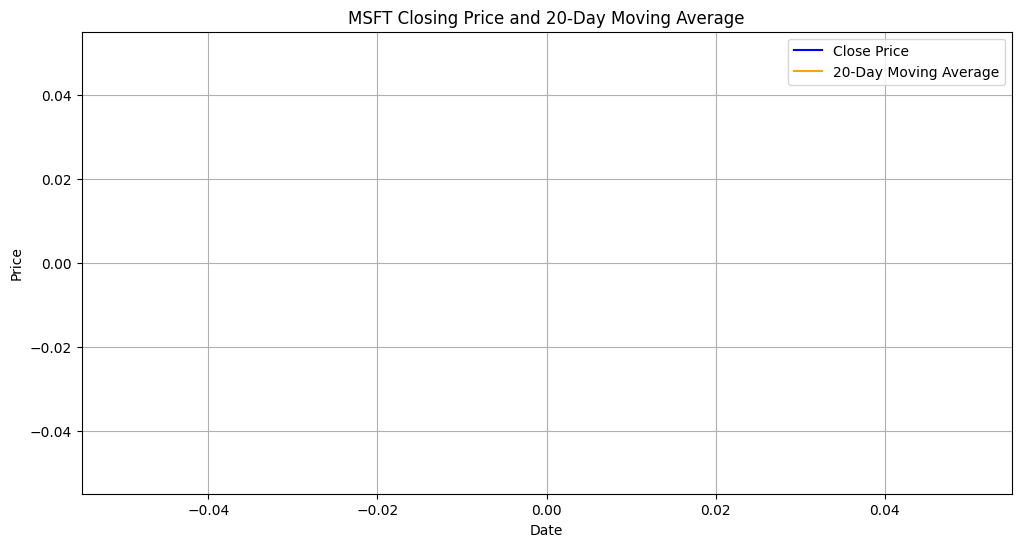

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

symbol = 'MSFT'
start_date = '2023-01-01'
end_date = '2023-12-31'

stock = yf.Ticker(symbol)
data = stock.history(start=start_date, end=end_date)

data['20_Day_MA'] = data['Close'].rolling(window=20).mean()

data['Daily_Return'] = data['Close'].pct_change() * 100

print("Data with Moving Average and Daily Returns:")
print(data[['Close', '20_Day_MA', 'Daily_Return']].head())

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['20_Day_MA'], label='20-Day Moving Average', color='orange')
plt.title(f'{symbol} Closing Price and 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate a date range of 250 days
dates = pd.date_range(start='2020-01-01', periods=250, freq='D')

# Generate random data for 15 feature columns
features = pd.DataFrame(np.random.randn(250, 15), 
                        columns=[f'feature{i+1}' for i in range(15)], 
                        index=dates)

# Generate a random 'return' column
returns = pd.Series(np.random.randn(250), index=dates, name='return')

# Generate a random 'market_regime' column with values between 0 and 3
market_regime = pd.Series(np.random.randint(0, 4, size=250), index=dates, name='market_regime')

# Combine everything into one DataFrame
df = pd.concat([features, returns, market_regime], axis=1)

# Display the first few rows of the DataFrame
df.head()


,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,feature11,feature12,feature13,feature14,feature15,return,market_regime
2020-01-01,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.585928,3
2020-01-02,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,0.329107,2
2020-01-03,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0.738467,0.171368,-0.115648,-0.301104,-1.478522,1.252843,1
2020-01-04,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,-0.448225,3
2020-01-05,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,0.361396,1.538037,-0.035826,1.564644,-2.619745,-0.692250,3
